# Stage 5: Data Visualization & Business Insight Generation
---
## Load data from MySQL database

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import get_db_connection
engine = get_db_connection()
query = "SELECT * FROM master_analytical_view"
df = pd.read_sql(query, engine)
plt.style.use('seaborn-v0_8-darkgrid') # Adds a clean background grid
plt.rcParams['figure.figsize'] = (10, 6) # Default figure size
plt.rcParams['font.size'] = 12

INFO: Successfully connected to the MySQL database.


# Visualizing the database to answer questions defined in the ASK stage
---

## <b>Topic 1:-</b> Sales & Revenue Trends (The Bottom Line)
---
***Question 1.1:- MoM Growth: What is the total revenue generated month-over-month, and are there distinct seasonal spikes (e.g., holiday seasons)?***
- *Approach:- We will plot the Month-over-Month (MoM) revenue using a **Line Chart** to visualize the overall growth and seasonal spikes over time.*

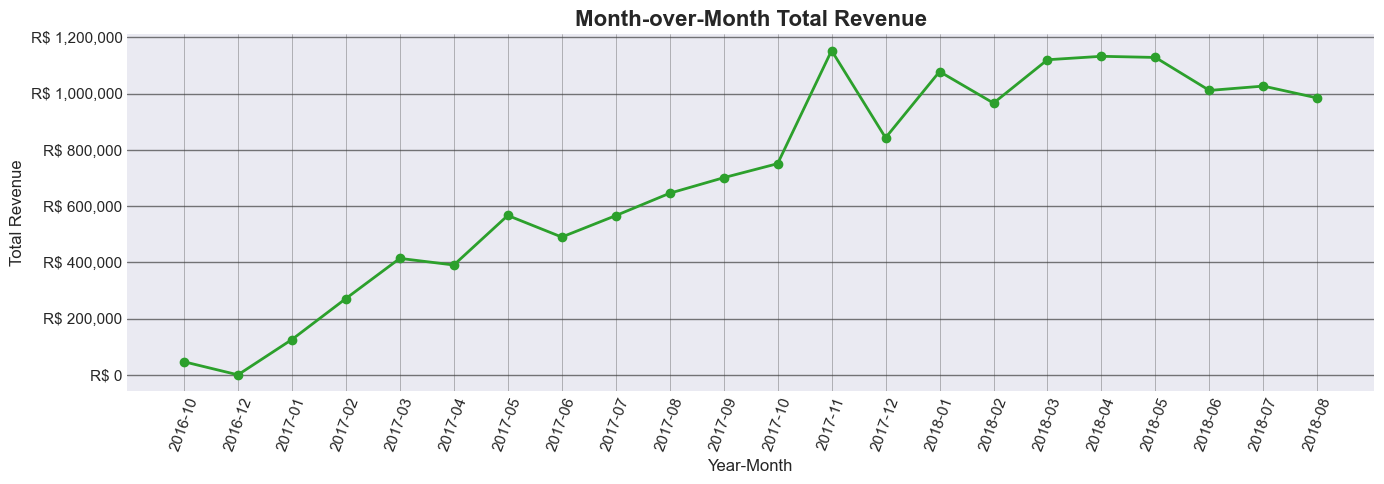

In [2]:
# Prepare Data
successful_orders = df[df['order_status'] == 'delivered'].drop_duplicates(subset=['order_id'])
monthly_revenue = successful_orders.groupby(['purchase_year', 'purchase_month'])['total_payment_value'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['purchase_year'].astype(str) + '-' + monthly_revenue['purchase_month'].astype(str).str.zfill(2)

# Plot
plt.figure(figsize=(14, 5))
# Fix: Use range(len(...)) to avoid the categorical parsing warning
plt.plot(range(len(monthly_revenue)), monthly_revenue['total_payment_value'], marker='o', color='#2ca02c', linewidth=2)
plt.title('Month-over-Month Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(ticks=range(len(monthly_revenue)), labels=monthly_revenue['year_month'], rotation=70, fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('R$ {x:,.0f}'))
plt.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.grid(axis='y', color='#404040', linewidth=1.0, alpha=0.7)
plt.grid(axis='x', color='#575757', linewidth=0.4, alpha=0.7)
plt.savefig('VIZ-1.1-LINE_CHART-MoM_Total_Revenue.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A line chart is the standard and most effective way to display trends over time. It clearly shows the progression, peaks, and troughs of revenue, making it easy for stakeholders to spot seasonal spikes.

**Insights for Stakeholders:**
Revenue trends show clear seasonality with peaks in November (Black Friday). Growth was consistent through November 2017; however, the post-2017 trend shifts toward a horizontal or downward slope, suggesting a slowdown in momentum.


**Strategic Recommendations:**  
Objective: Identify and leverage the root causes of performance spikes.
- <u>Seasonal Dynamics:</u>
Analyze the core drivers of historical performance peaks, such as holiday demand or high-impact marketing. If November demonstrates consistent growth, prioritize Q4 budget allocation and inventory scaling. To mitigate volatility, implement targeted promotions during historically slow periods to stabilize year-round revenue.  
- <u>Innovative Ideas:</u>
Evaluate the specific "innovative ideas" that fueled initial success to replicate their impact. To regain and accelerate momentum, transition from sporadic breakthroughs to a structured R&D model. Increasing investment in specialized talent will ensure a continuous innovation pipeline, moving the brand beyond a reliance on "one-off" hits.

---
***Question 1.2:- Peak Traffic: Which day of the week (purchase_day_of_week) and hour of the day (purchase_hour) see the highest volume of successful orders? (Actionable for timing marketing blasts or flash sales).***
- *Approach:- We will use a **Heatmap** to show the intersection of days and hours, highlighting the busiest times for purchases.*

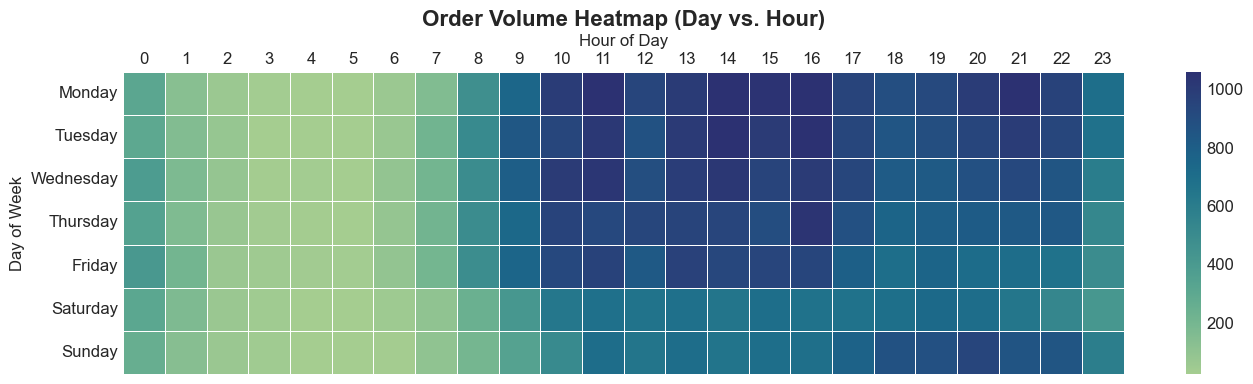

In [3]:
# Prepare Data
heatmap_data = successful_orders.groupby(['purchase_day_of_week', 'purchase_hour'])['order_id'].count().unstack()
# Reorder days logically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

# Plot
plt.figure(figsize=(14, 4)) # recommended (14, 6)
sns.heatmap(heatmap_data, cmap='crest', annot=False, linewidths=.4, robust=True)
plt.title('Order Volume Heatmap (Day vs. Hour)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.xlabel('Hour of Day', fontsize=12)
plt.gca().xaxis.set_label_position('top') 
plt.gca().xaxis.tick_top()
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.savefig('VIZ-1.2-HEATMAP-Order_Volume.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:**
A heatmap is highly effective for visualizing event density across two dimensions (days of the week and hours of the day). The color gradients allow stakeholders to instantly identify periods of peak traffic and customer activity.

**Insights for Stakeholders:**  
In the heatmap, darker blue areas represent the highest volume of orders, while lighter green areas indicate periods of lower activity.
- Weekday Peaks: Weekdays between 10 AM and 4 PM display the darkest blue shades, indicating that the majority of our customers shop during standard working hours.
- Weekend Drop-off: Saturdays show a transition to lighter green and mid-tone blue shades. This indicates a noticeable decline in order volume compared to the core weekday peaks, highlighting an area of untapped potential.

**Real-world Suggestion:**
- Marketing Optimization: Leverage the high-traffic weekday windows to maximize the reach of email marketing blasts, app push notifications, and flash sales. To stimulate the lower-performing Saturday segments, deploy targeted "weekend-exclusive" promotions.
- Operational Efficiency: Schedule routine website maintenance and system updates during the lightest green (lowest traffic) hours to minimize disruption to the customer experience.

---
***Question 1.3:- AOV (Average Order Value): What is the average amount a customer spends per transaction, and how does this change over the years?***
- *Approach:- We will use a **Bar Chart** to show the year-over-year comparison of the Average Order Value.*

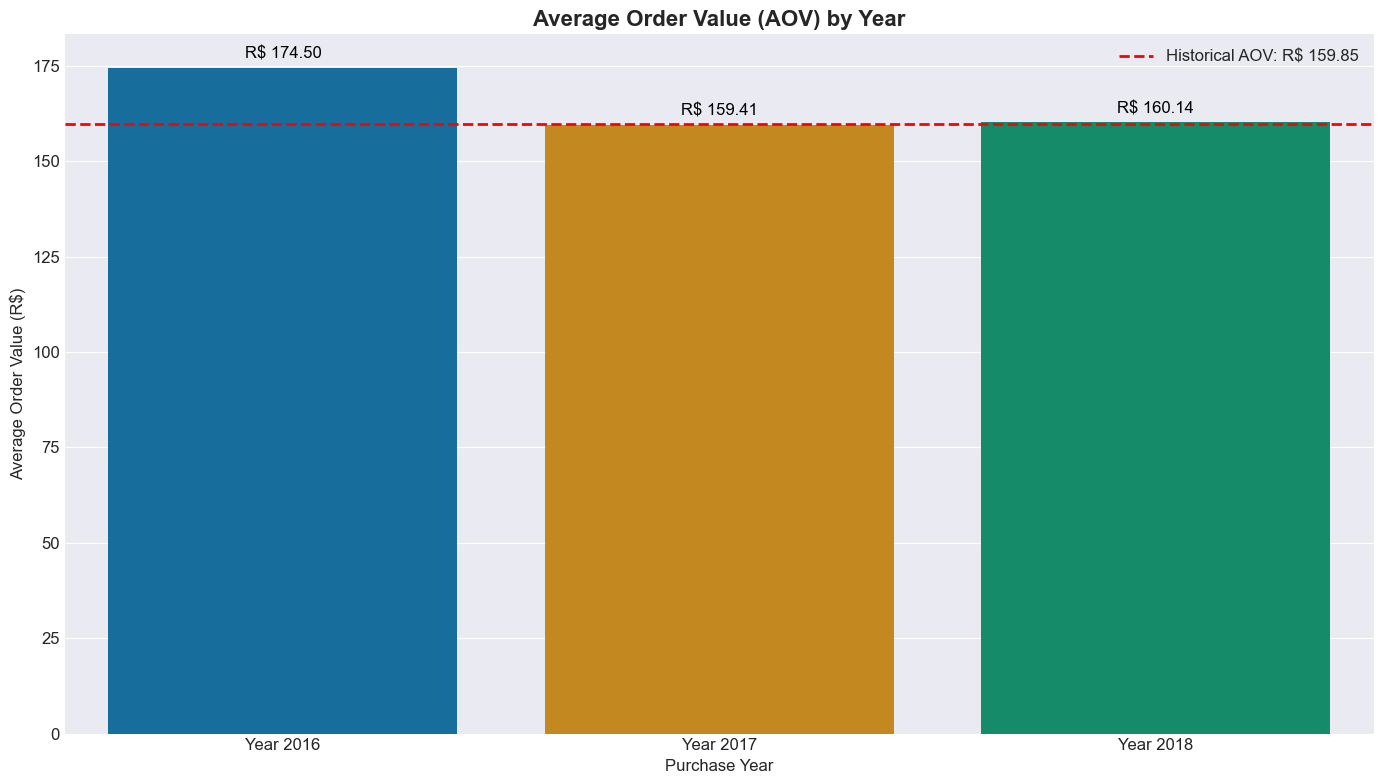

In [4]:
# Prepare Data
# Create orders_unique to ensure we don't double-count orders with multiple items
orders_unique = df.drop_duplicates(subset=['order_id']).copy()

overall_aov = orders_unique['total_payment_value'].mean()
aov_by_year = orders_unique.groupby('purchase_year')['total_payment_value'].mean().reset_index()

# THE ROOT CAUSE FIX:
# Explicitly format as text so Matplotlib stops confusing the strings for floats.
aov_by_year['purchase_year'] = 'Year ' + aov_by_year['purchase_year'].astype(str)

# Plot
plt.figure(figsize=(14, 8))   # recommended (10, 6)
ax = sns.barplot(data=aov_by_year, x='purchase_year', y='total_payment_value', hue='purchase_year', palette='colorblind', legend=False)
plt.axhline(overall_aov, color='red', linestyle='--', linewidth=2, label=f'Historical AOV: R$ {overall_aov:.2f}')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f"R$ {p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='center', 
                fontsize=12, color='black', xytext=(0, 10),textcoords='offset points')

plt.title('Average Order Value (AOV) by Year', fontsize=16, fontweight='bold')
plt.xlabel('Purchase Year', fontsize=12)
plt.ylabel('Average Order Value (R$)', fontsize=12)

# This legend() call will now only show the red dashed line, which is exactly what we want!
plt.legend() 
plt.tight_layout()
plt.savefig('VIZ-1.3-BAR_CHART-AOV_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A bar chart with a horizontal baseline (historical AOV) allows viewers to instantly see whether a specific year underperformed or overperformed compared to the historical average. 

**Insights for Stakeholders:**
The AOV dropped slightly from 2016 to 2017 but stabilized going into 2018. This indicates that while order volume may be increasing, customers are consistently spending around ~R$ 160 per transaction.

**Real-world Suggestion:**
Since AOV is stagnant, implement "bundle deals" (e.g., buy a laptop, get a mouse for 10% off) or free shipping thresholds (e.g., "Free shipping on orders over R$ 200") to encourage customers to add more items to their carts.

---
## <b>Topic 2:-</b> Logistics & Operational Efficiency
---
***Question 2.1:- Delivery Baselines: What is the average delivery_time_days across the platform, and which specific states suffer from the slowest average deliveries?***
- *Approach:- We will use a **Horizontal Bar Chart** to rank the top 10 slowest states, making the geographical text labels easy to read.*

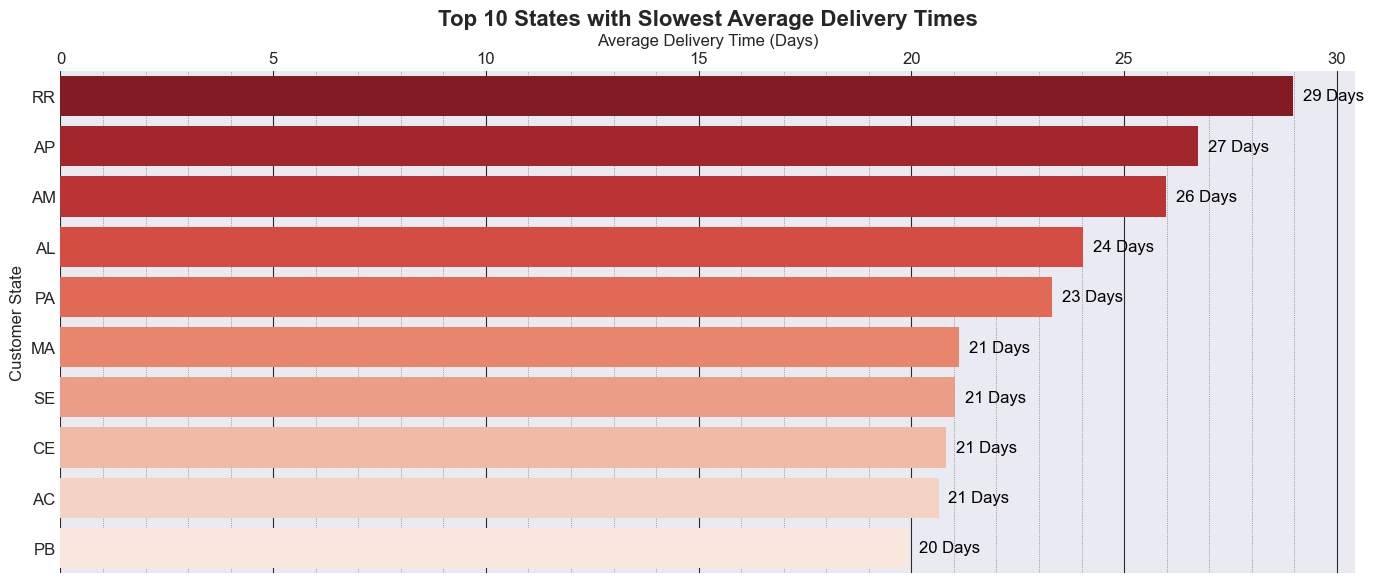

In [5]:
# Prepare Data
state_delivery_times = orders_unique.groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False).head(10).reset_index()

# Plot
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=state_delivery_times, y='customer_state', x='delivery_time_days', hue='customer_state', palette='Reds_r', legend=False)
plt.title('Top 10 States with Slowest Average Delivery Times', fontsize=16, fontweight='bold')
plt.xlabel('Average Delivery Time (Days)', fontsize=12)
plt.gca().xaxis.set_label_position('top') 
plt.gca().xaxis.tick_top()
plt.ylabel('Customer State', fontsize=12)
plt.minorticks_on()
plt.grid(which='minor', axis='x', color='#424242', linestyle=':', linewidth=0.5, alpha=0.8)
plt.grid(which='major', axis='x', color='#2b2b2b', linewidth=0.8)
# Add value labels to the right of horizontal bars
for p in ax.patches:
    value = p.get_width()
    ax.annotate(f"{value:,.0f} Days", (value, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=12, color='black', xytext=(7, 0), 
                textcoords='offset points')
plt.tight_layout()
plt.savefig('VIZ-2.1-HORIZONTAL_BAR_CHART-Top_10_States_with_Slowest_Average_Delivery_Times.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A horizontal bar chart is the best practice for ranking categorical data with potentially long names (or state codes). It forces the viewer to read from top to bottom, immediately spotting the worst offenders.

**Insights for Stakeholders:**
Northern and Northeastern states like RR (Roraima), AP (Amapá), and AM (Amazonas) dominate the top of the list, frequently taking over 25 days for delivery due to geographical isolation from the main industrial hubs.

**Real-world Suggestion:**
Set clear, realistic delivery expectations at checkout for customers in these states to avoid negative reviews. Additionally, consider opening a secondary regional distribution center in the North/Northeast to cut transit times.

---
***Question 2.2:- The Cost of Delay: What proportion of our successful orders are actually delivered late to the customer?***
- *Approach:- We will use a **Pie Chart** (or Donut Chart) to show the strict percentage breakdown of On-Time vs. Late deliveries to give stakeholders a clear view of our logistical reliability.*

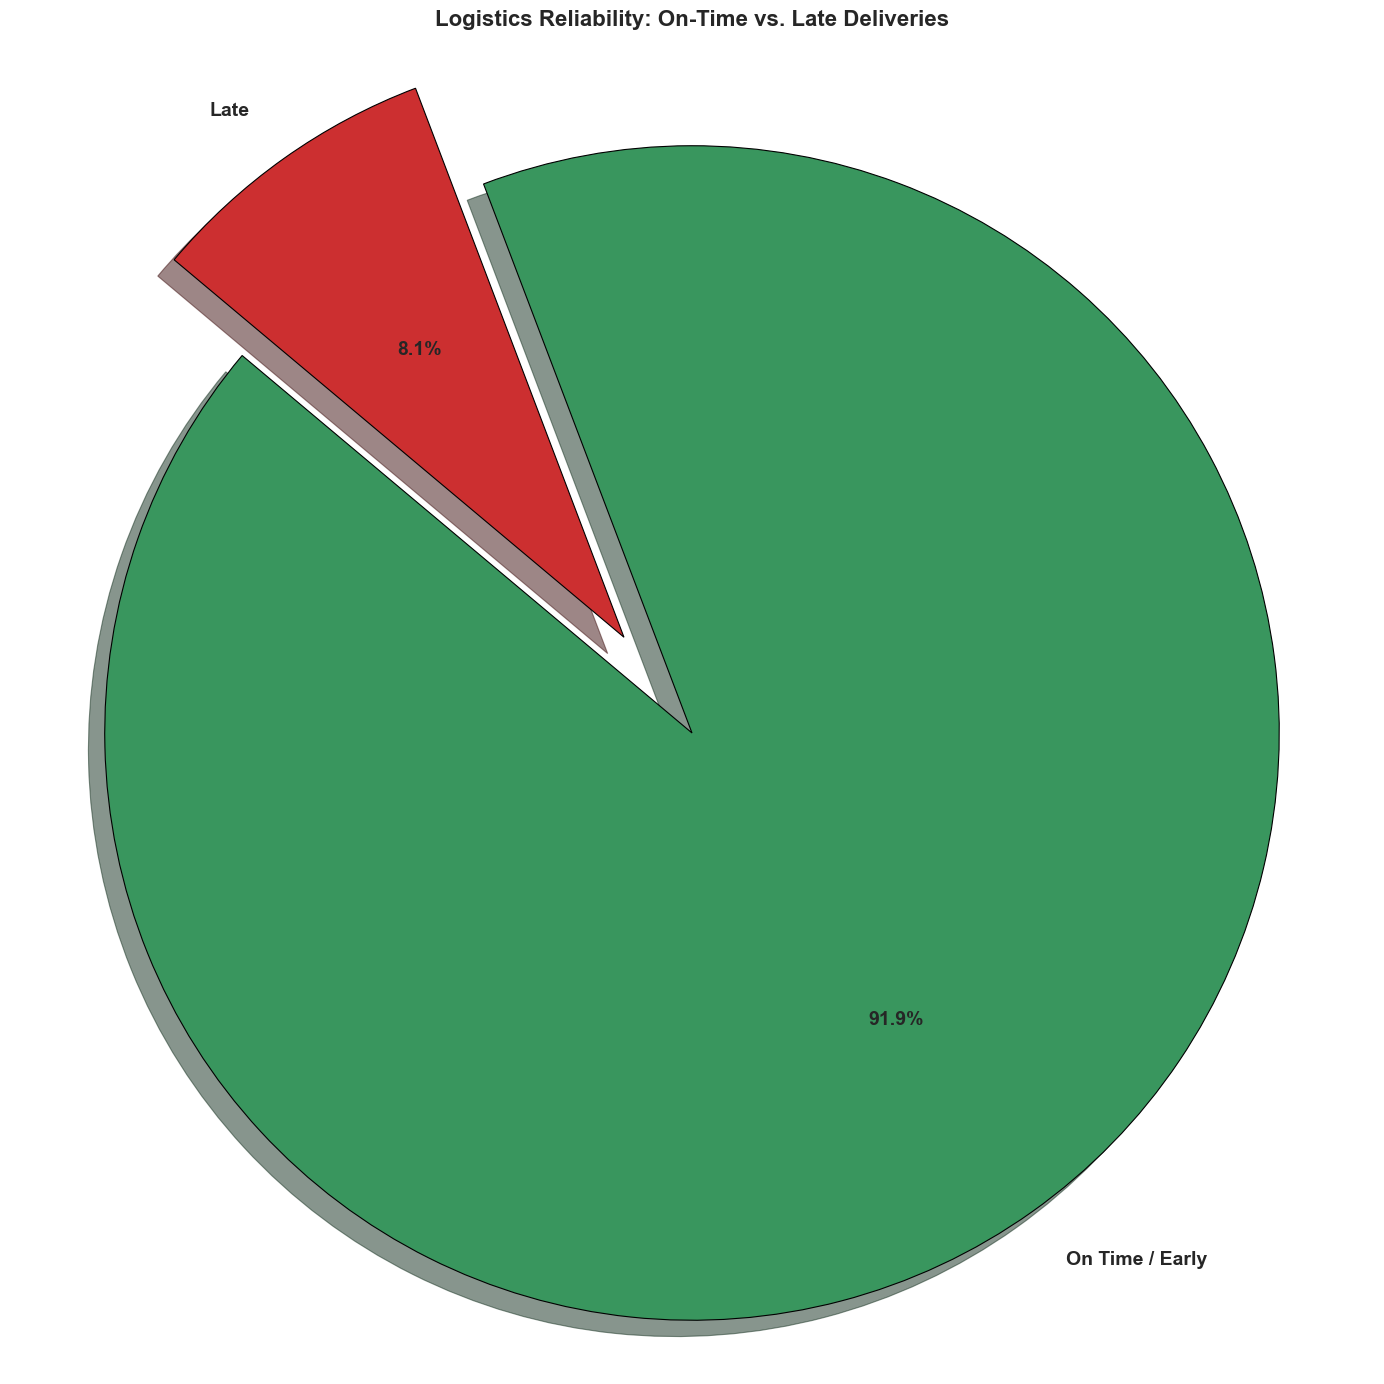

In [6]:
# Prepare Data
# Filter only delivered orders to compare estimated vs actual delivery dates
delivered_orders = orders_unique[orders_unique['order_status'] == 'delivered'].copy()
# Ensure datetime format
delivered_orders['order_estimated_delivery_date'] = pd.to_datetime(delivered_orders['order_estimated_delivery_date'])
delivered_orders['order_delivered_customer_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])
# Create a boolean column for late deliveries
delivered_orders['is_late'] = delivered_orders['order_delivered_customer_date'] > delivered_orders['order_estimated_delivery_date']
# Count occurrences
delivery_performance = delivered_orders['is_late'].value_counts().rename(index={False: 'On Time / Early', True: 'Late'})

# Plot
plt.figure(figsize=(14, 14))
colors = ['#39965e', '#cc2f30'] # Green for On Time, Red for Late
explode = (0, 0.2) # Pop out the 'Late' slice for emphasis
plt.pie(delivery_performance, labels=delivery_performance.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode, shadow=True, 
        wedgeprops={'linewidth': 0.8, 'edgecolor': 'black', 'linestyle': '-'}, textprops={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Logistics Reliability: On-Time vs. Late Deliveries', fontsize=16, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.savefig('VIZ-2.2-PIE_CHART-Logistics_Reliability_On-Time_vs_Late_Deliveries.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A pie/donut chart is highly effective for binary proportions (A vs B) where the parts make up a whole 100%. Exploding the "Late" slice immediately draws the stakeholder's eye to the problem area.

**Insights for Stakeholders:**
The visual shows exactly what percentage of our logistics network is failing to meet the promised delivery date. Even if the late percentage is small (e.g., 6-8%), at the scale of thousands of orders, this represents a massive number of frustrated customers.

**Real-world Suggestion:**
Compare the "Estimated Delivery Date" algorithm against real-world transit times. It is better to over-estimate delivery times at checkout and deliver early (under-promise, over-deliver) than to promise a fast delivery and arrive late.

---
***Question 2.3:- Freight Impact: How does the freight_ratio (the cost of shipping relative to the item price) affect purchasing behavior? Do higher freight ratios lead to more canceled orders?***
- *Approach:- We will plot a **Bar Chart** showing the cancellation rate across different freight cost brackets to see if expensive shipping drives customers away.*

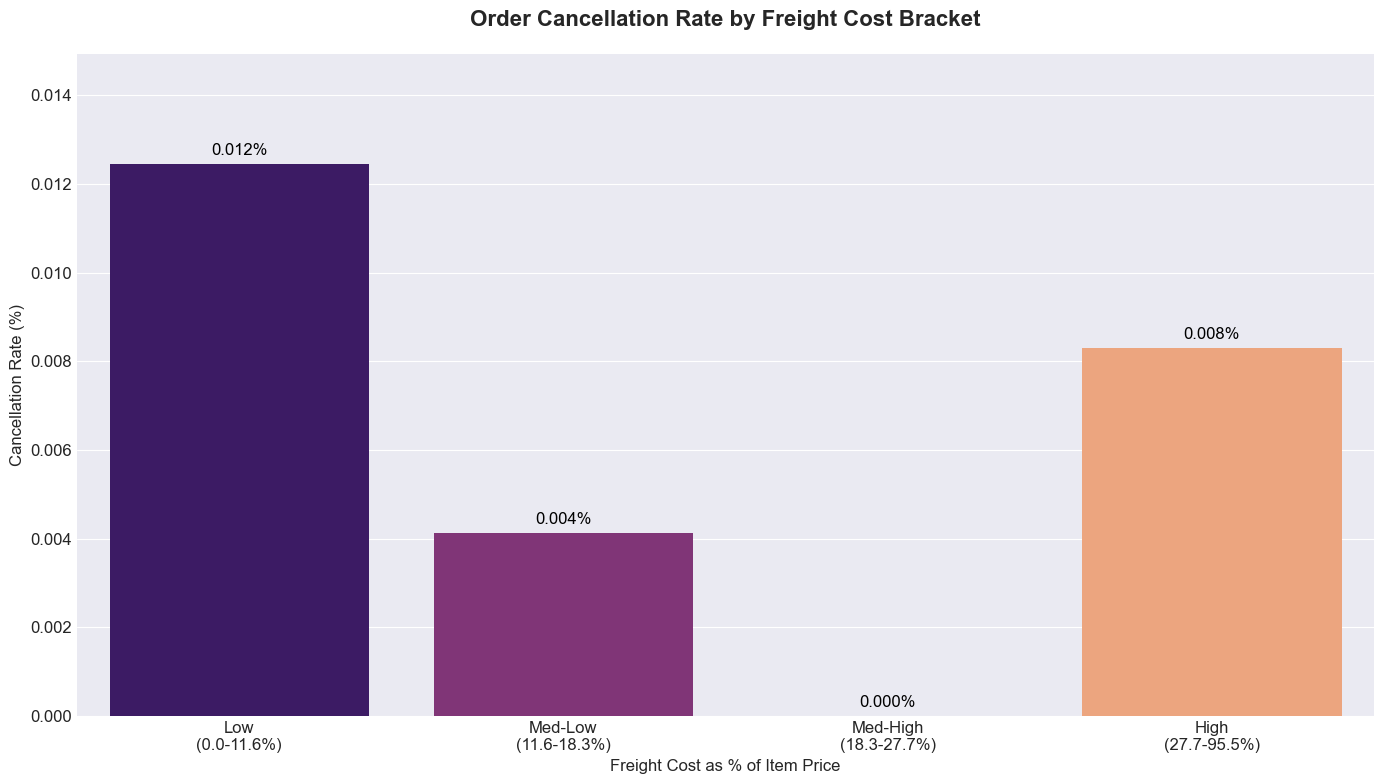

In [7]:
# Prepare Data
orders_unique_freight = orders_unique.copy()
# orders_unique_freight['freight_ratio']  = df.groupby('order_id')['freight_value'].mean() / df.groupby('order_id')['price'].sum()

# Calculate the raw bins to get the numerical edges. We use retbins=True to get the actual math boundaries
_, bins = pd.qcut(orders_unique_freight['freight_ratio'], q=4, retbins=True, duplicates='drop')

# Create descriptive labels including the percentages. bins[0]*100 to bins[1]*100, etc.
bin_labels = [
    f"Low\n({bins[0]*100:.1f}-{bins[1]*100:.1f}%)",
    f"Med-Low\n({bins[1]*100:.1f}-{bins[2]*100:.1f}%)",
    f"Med-High\n({bins[2]*100:.1f}-{bins[3]*100:.1f}%)",
    f"High\n({bins[3]*100:.1f}-{bins[4]*100:.1f}%)"
]

# Apply the qcut with our new descriptive labels
orders_unique_freight['freight_bracket'] = pd.qcut(orders_unique_freight['freight_ratio'], q=4, labels=bin_labels, duplicates='drop')

# Calculate Rates
orders_unique_freight['is_canceled'] = np.where(orders_unique_freight['order_status'] == 'canceled', 1, 0)
cancellation_rates = orders_unique_freight.groupby('freight_bracket', observed=True)['is_canceled'].mean() * 100

# Plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(x=cancellation_rates.index, y=cancellation_rates.values, hue=cancellation_rates.index, palette='magma',legend=False)
plt.title('Order Cancellation Rate by Freight Cost Bracket', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Freight Cost as % of Item Price', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}%", (p.get_x() + p.get_width() / 2., p.get_height()),ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),textcoords='offset points')

# Adjust Y-axis to make room for labels
plt.ylim(0, cancellation_rates.max() * 1.2)
plt.tight_layout()
plt.savefig('VIZ-2.3-BAR_CHART-Order_Cancellation_Rate_by_Freight_Cost_Bracket.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A vertical bar chart effectively displays the progression of ordinal data (categorized from Low to High shipping costs, representing freight cost as a percentage of the item price). By labeling the data points with exact percentages, stakeholders can clearly identify the non-linear distribution and easily compare the varying cancellation rates across different cost brackets.

**Insights for Stakeholders:**
* Overall, the cancellation rates appear nominally low across all brackets (all under 0.015%). However, at high transaction volumes, these marginal percentages still represent a significant absolute number of canceled orders and lost revenue.
* Surprisingly, the highest cancellation rate (**0.012%**) occurs in the **Low** bracket, where freight cost is only 0.0% to 11.6% of the item price. This suggests that for these orders (likely high-ticket/expensive items where shipping is a tiny fraction of the cost), freight is *not* the primary driver of cancellations. Factors like buyer's remorse or finding a better price elsewhere are more probable causes.
* In the **High** bracket (freight cost 27.7% to 95.5%), we see the second-highest cancellation rate (**0.008%**). Here, shipping is almost as expensive as the item itself. Customers likely experience "sticker shock" at checkout, where disproportionately high shipping costs ruin the perceived value of a cheaper item, leading directly to cancellations.
* The **Med-High** bracket (18.3% to 27.7%) shows a **0.000%** cancellation rate, indicating a highly efficient "sweet spot" where customers are most tolerant of the shipping fees relative to the product price.

**Real-world Suggestion:**
Implement a shipping cap or flat-rate shipping for low-value items (which typically fall into the High freight cost bracket) to mitigate "sticker shock." Alternatively, introduce a minimum cart value to unlock free or discounted shipping. This encourages customers to add more items to their cart, effectively diluting the freight cost percentage to align with the highly stable "Med-High" bracket (<27.7%), while simultaneously increasing your Average Order Value (AOV).

---
## <b>Topic 3:-</b> Customer Behavior & Segmentation
---
***Question 3.1:- Payment Preferences: What is the distribution of payment_type? Do customers using credit cards have a significantly higher AOV than those using other methods?***
- *Approach:- We will use a **Bar Chart** to show the volume of transactions for each payment type to understand how our customers prefer to pay.*

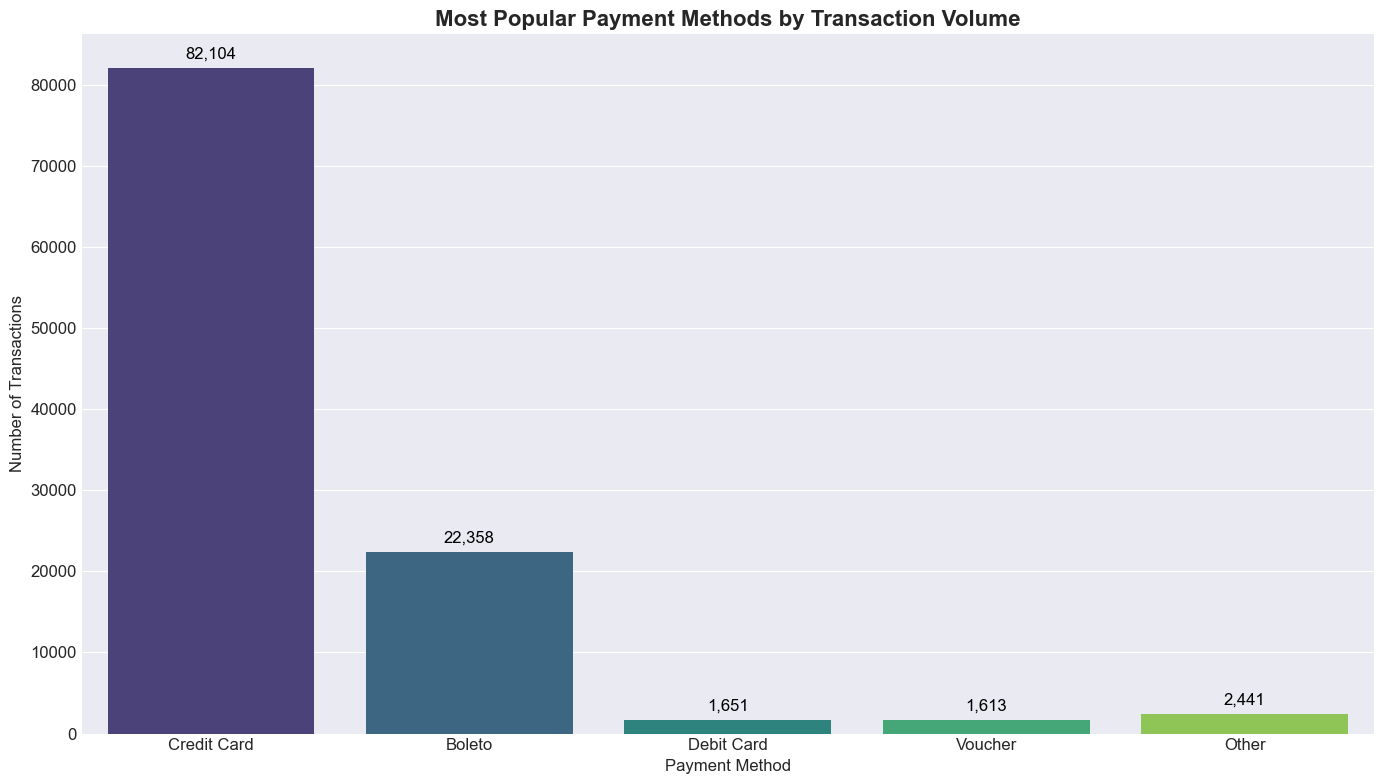

In [8]:
# Prepare Data
# Count the occurrences of each payment type, excluding 'not_defined' if it exists
payment_prefs = df['payment_type'].value_counts().reset_index()
payment_prefs.columns = ['payment_type', 'transaction_count']
payment_prefs = payment_prefs[payment_prefs['payment_type'] != 'not_defined']
# Group 5th category and beyond into 'Other' ---
top_n = 4 # Number of distinct categories to keep before grouping
if len(payment_prefs) > top_n:
    # Separate the top 4 and the rest
    top_categories = payment_prefs.iloc[:top_n].copy()
    other_sum = payment_prefs.iloc[top_n:]['transaction_count'].sum()
    # Create a new DataFrame for the 'Other' row
    other_row = pd.DataFrame({'payment_type': ['Other'], 'transaction_count': [other_sum]})
    # Combine the top categories with the new 'Other' row
    payment_prefs = pd.concat([top_categories, other_row], ignore_index=True)

# Clean up the labels for the chart
payment_prefs['payment_type'] = payment_prefs['payment_type'].str.replace('_', ' ').str.title()

# Plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=payment_prefs, x='payment_type', y='transaction_count', hue='payment_type', palette='viridis', legend=False)
plt.title('Most Popular Payment Methods by Transaction Volume', fontsize=16, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Add comma-formatted value labels on top of bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, 
                color='black', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.savefig('VIZ-3.1-BAR_CHART-Most_Popular_Methods_by_Transaction_Volume.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A standard vertical bar chart is the most effective way to compare absolute categories (payment types). It immediately highlights the dominant method without the visual distortion sometimes caused by pie charts. Additionally, grouping smaller contributing categories into a single "Other" bar further reduces visual clutter.

**Insights for Stakeholders:**
Credit cards are overwhelmingly the most preferred payment method, dominating the transaction volume. "Boleto" (a popular cash-based payment method in Brazil) is a distant second, while debit cards and vouchers make up a very small minority of purchases.

**Real-world Suggestion:**
Since credit cards are the primary driver of sales, ensure the payment gateway has the highest possible uptime and low failure rates for card processing. For the "Boleto" users, consider sending automated SMS reminders to pay the boleto before it expires to reduce unpaid, canceled orders.

---

***Question 3.2:- Installment Psychology: Does the availability of payment_installments correlate with customers buying more expensive items (total_item_value)?***
- *Approach:- We will use a **Scatter Plot with a Regression Line** to mathematically show the relationship between the number of payment installments and the total order value.*

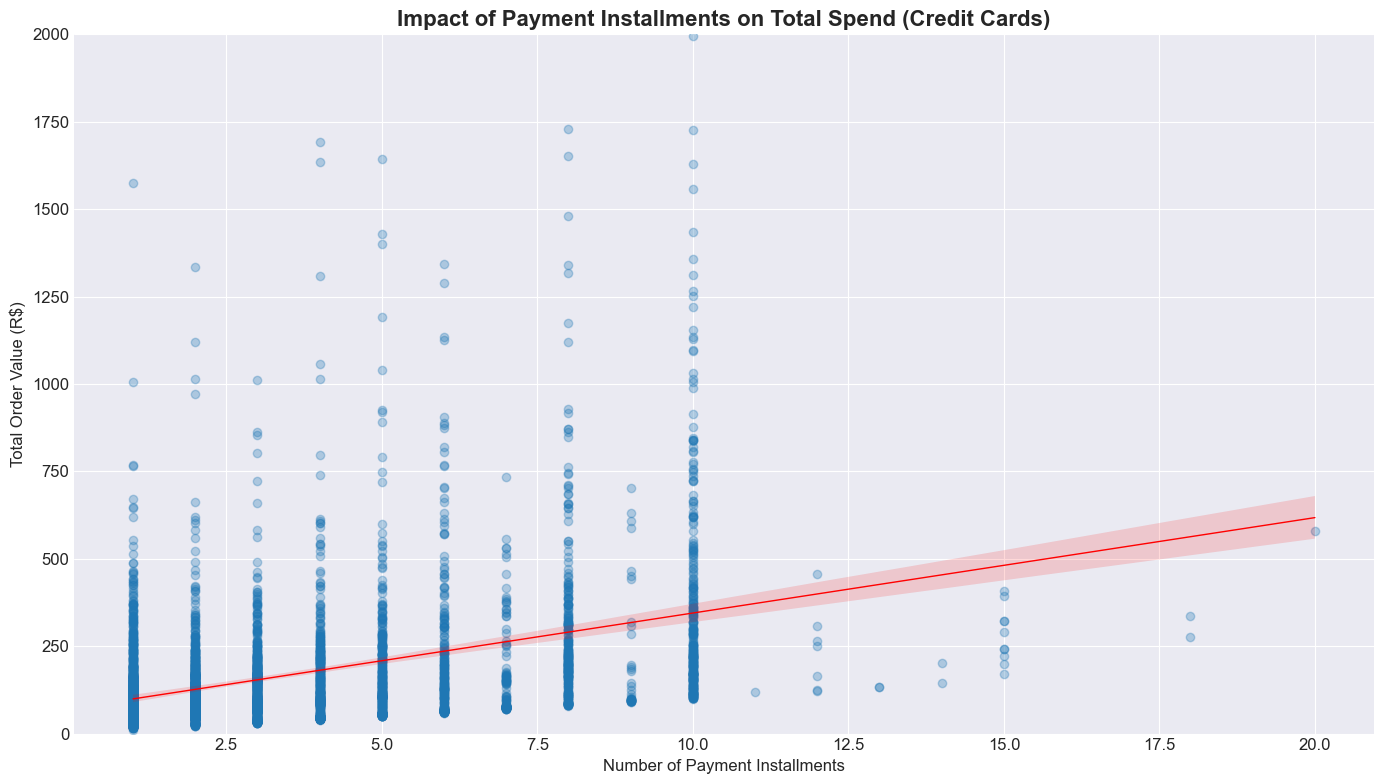

In [9]:
# Prepare Data
# Ensure we only look at credit card payments, as installments mostly apply there
credit_card_orders = df[df['payment_type'] == 'credit_card'].drop_duplicates(subset=['order_id'])
# We use a sample of 5,000 rows, which will show similar results to avoid overplotting since the dataset is very large, with 72,104 rows
sample_orders = credit_card_orders.sample(n=5000, random_state=42)

# Plot
plt.figure(figsize=(14, 8))
sns.regplot(data=sample_orders, x='payment_installments', y='total_payment_value', scatter_kws={'alpha':0.3, 'color':'#1f77b4'}, 
            line_kws={'color':'red', 'linewidth':1})
plt.title('Impact of Payment Installments on Total Spend (Credit Cards)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Payment Installments', fontsize=12)
plt.ylabel('Total Order Value (R$)', fontsize=12)
# Cap the Y-axis to remove extreme outliers and show the general trend clearly
plt.ylim(0, 2000)
plt.tight_layout()
plt.savefig('VIZ-3.2-SCATTER_PLOT-Impact_of_Payment_Installments_on_Total_Spend.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A scatter plot with a regression trend line (in red) is the industry standard for proving correlation between two continuous/numerical variables. The upward slope visually confirms to stakeholders whether more installments equal bigger baskets.

**Insights for Stakeholders:**
There is a clear positive correlation. As the number of available installments increases, the `total_payment_value` goes up. Customers are much more willing to buy expensive items (like electronics or furniture) if they can spread the cost over 10 to 12 months.

**Real-world Suggestion:**
Promote "Buy Now, Pay Later" or "Up to 12x Interest-Free Installments" heavily on the homepage and on product pages for high-ticket items. This reduces purchase friction and directly drives up the Average Order Value (AOV).

---
***Question 3.3:- High-Value Customers (RFM Prep): Which top 10 cities have the highest concentration of customers in the top 5% based on total payment value?***
- *Approach:- We will identify the top 5% of spenders and use a **Horizontal Bar Chart** to map the Top 10 cities where these VIP customers reside.*

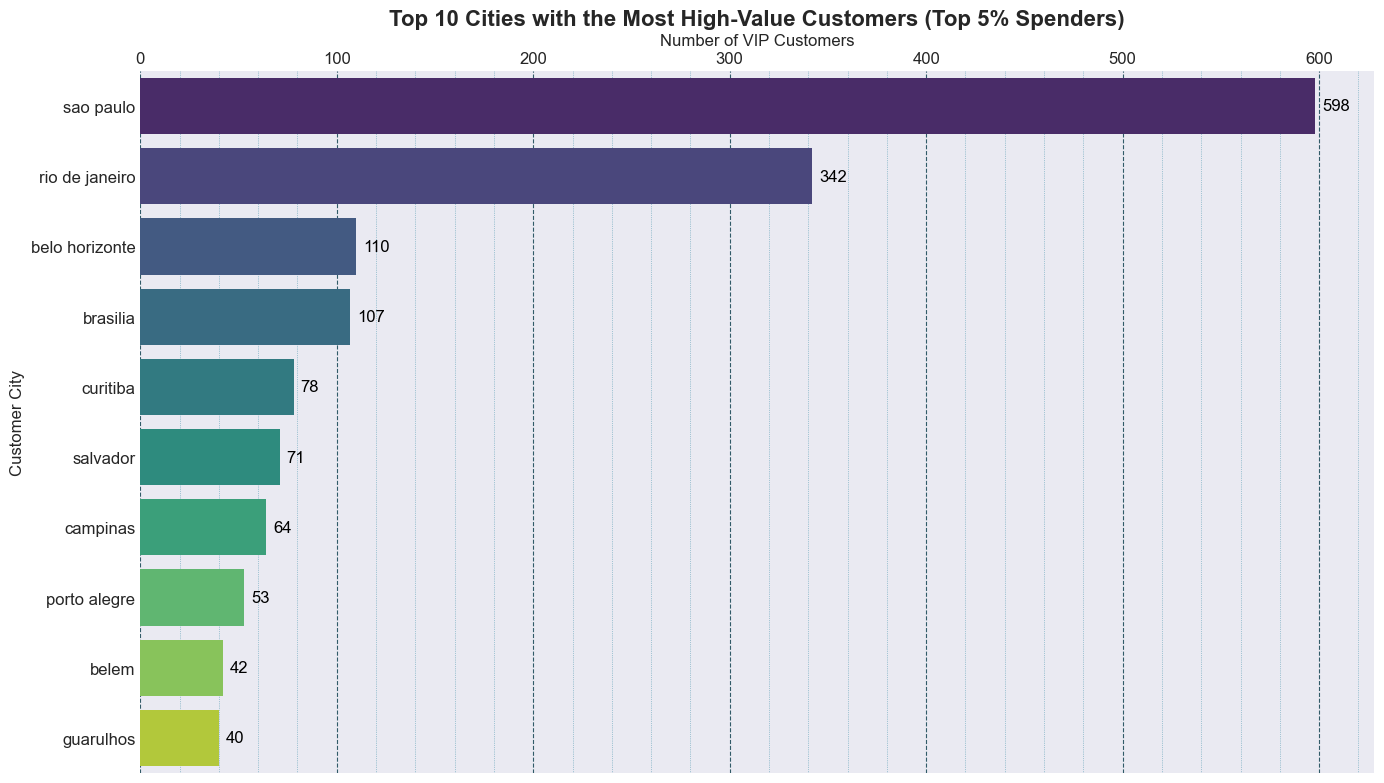

In [10]:
# Prepare Data
# 1. Calculate total spend per unique customer
customer_spend = orders_unique.groupby(['customer_unique_id', 'customer_city']).agg(
    total_spend=('total_payment_value', 'sum'), total_orders=('order_id', 'nunique')).reset_index()
# 2. Find the 95th percentile threshold
top_5_threshold = customer_spend['total_spend'].quantile(0.95)
# 3. Filter for High-Value Customers (HVCs) whose spending is above the 95th percentile threshold.
high_value_customers = customer_spend[customer_spend['total_spend'] >= top_5_threshold]
# 4. Count how many HVCs live in each city
city_hvc_counts = high_value_customers['customer_city'].value_counts().head(10).reset_index()
city_hvc_counts.columns = ['customer_city', 'hvc_count']

# Plot
plt.figure(figsize=(14, 8)) #recomended (12, 7)
ax = sns.barplot(data=city_hvc_counts, y='customer_city', x='hvc_count', hue='customer_city', palette='viridis', legend=False)
plt.title('Top 10 Cities with the Most High-Value Customers (Top 5% Spenders)', fontsize=16, fontweight='bold')
plt.xlabel('Number of VIP Customers', fontsize=12)
plt.gca().xaxis.set_label_position('top') 
plt.gca().xaxis.tick_top()
plt.ylabel('Customer City', fontsize=12)
# Add value labels next to the bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y() + p.get_height() / 2.),ha='left', va='center', fontsize=12, color='black', 
                xytext=(5, 0),textcoords='offset points')
plt.minorticks_on()
plt.grid(which='minor', axis='x', color='#378ca6', linestyle=':', linewidth=0.5, alpha=0.8)
plt.grid(which='major', axis='x', color='#1d4b59', linestyle='--', linewidth=0.8, alpha=0.9)
plt.tight_layout()
plt.savefig('VIZ-3.3-HORIZONTAL_BAR_CHART-Top_10_Cities_with_Top_5_percent_Spenders.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A horizontal bar chart is the industry standard for ranking categorical data, especially when dealing with geographic locations or long text labels. Comparing the top 10 cities in which the top 5% costomers resides allows stakeholders to instantly identify the dominant regions without having to guess the numbers from the gridlines.

**Insights for Stakeholders:**
There is a massive geographic concentration of high-value purchasing. São Paulo completely dominates the VIP customer base, containing nearly double the amount of top-tier spenders (598) compared to the second-place city, Rio de Janeiro (342). After these top two metropolitan hubs, there is a steep and immediate drop-off, with the remaining cities hovering around 100 VIPs or fewer.

**Real-world Suggestion:**
Geofence your premium marketing and VIP retention budgets. Launch highly targeted campaigns (like exclusive early-access sales or dedicated account managers) specifically for users in São Paulo and Rio de Janeiro. Additionally, to protect this core revenue stream, consider investing in localized, premium logistics (such as guaranteed same-day delivery or white-glove courier services) exclusively in these major hubs to keep these "whales" loyal.

---
## <b>Topic 4:-</b> Product Catalog & Satisfaction
---

***Question 4.1:- Volume vs. Value: Which product_category_name drives the highest total revenue, and which drives the highest volume of individual items sold?***
- *Approach:- We will use a **Dual-axis Bar and Line Chart** to contrast Pure Revenue (Cash Cows) against Items Sold (Velocity).*

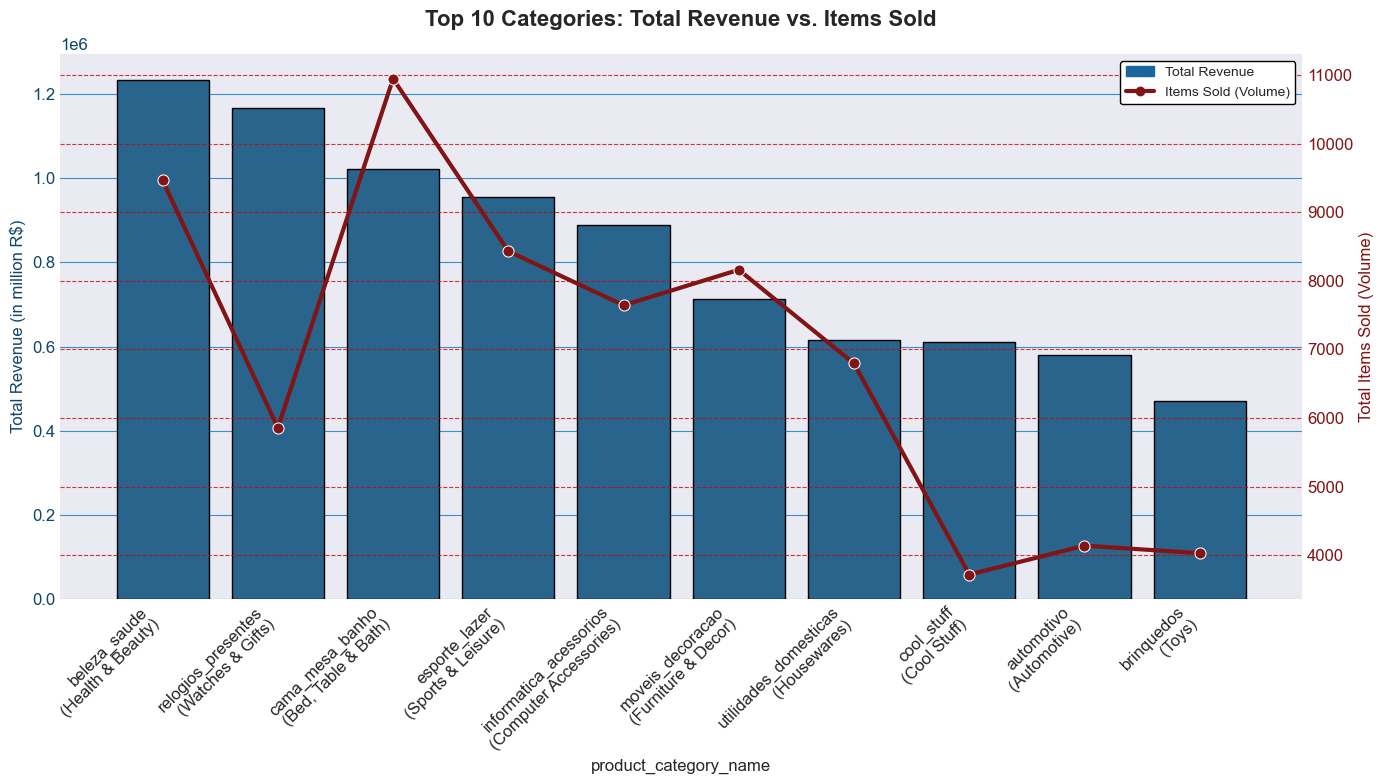

In [11]:
# PREPARE DATA
category_performance = df.groupby('product_category_name').agg(
    total_revenue=('price', 'sum'),total_items_sold=('order_item_id', 'count')).sort_values(by='total_revenue', ascending=False).head(10)
# The category names are in Portuguese, so we are adding the English names.
translation_map = {'beleza_saude': 'Health & Beauty', 'relogios_presentes': 'Watches & Gifts', 'cama_mesa_banho': 'Bed, Table & Bath', 'esporte_lazer': 'Sports & Leisure', 'informatica_acessorios': 'Computer Accessories', 'moveis_decoracao': 'Furniture & Decor', 'utilidades_domesticas': 'Housewares', 'cool_stuff': 'Cool Stuff', 'automotivo': 'Automotive', 'brinquedos': 'Toys'}
final_map = {k: f"{k}\n({v})" for k, v in translation_map.items()}
category_performance.index = category_performance.index.map(final_map)

# PLOT
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart for Revenue
sns.barplot(data=category_performance, x=category_performance.index, y='total_revenue', ax=ax1, color='#19679c', edgecolor="black")
ax1.set_ylabel('Total Revenue (in million R$)', fontsize=12, color='#10476b')
ax1.tick_params(axis='y', labelcolor='#10476b')
ax1.grid(axis='y', color='#0a78c2', linestyle='-', linewidth=0.8, alpha=0.8)
plt.xticks(rotation=45, ha='right')

# Line chart for Volume on secondary axis
ax2 = ax1.twinx()
sns.lineplot(data=category_performance, x=category_performance.index, y='total_items_sold', ax=ax2, color='#821415', marker='o', linewidth=3, markersize=8)
ax2.set_ylabel('Total Items Sold (Volume)', fontsize=12, color='#821415')
ax2.grid(axis='y', color='#c20a0a', linestyle='--', linewidth=0.8, alpha=0.8)
ax2.tick_params(axis='y', labelcolor='#821415')

# ADDING LEGEND
# Collect handles and labels from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# We can manually define the handles, since sns.barplot doesn't always provide a label automatically
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
# Create manual proxy artists for the legend
revenue_patch = mpatches.Patch(color='#19679c', label='Total Revenue')
volume_line = Line2D([0], [0], color='#821415', marker='o', linewidth=3, label='Items Sold (Volume)')
# Add the combined legend to the top right
ax2.legend(handles=[revenue_patch, volume_line], loc='upper right', frameon=True, fontsize=10, edgecolor='black', facecolor="white", framealpha=1.0)

plt.title('Top 10 Categories: Total Revenue vs. Items Sold', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()
plt.savefig('VIZ-4.1-BAR_AND_LINE_CHART-Total_Revenue_vs_Items_Sold.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** A dual-axis chart perfectly overlays two different metrics (currency vs. count). It lets us see where revenue is high but volume is comparatively lower (high-ticket items) versus where volume is massive but revenue is comparatively lower (high-velocity, cheaper items).

**Insights for Stakeholders:**
Categories like "beleza_saude" (Health & Beauty) generate the highest overall revenue. However, "cama_mesa_banho" (Bed, Bath & Table) drives the highest absolute volume of items sold.
We can also derive the average ticket size of a particular category by comparing the total revenue and total items. For example, the ticket size of the category "relogios_presentes" (Watches & Gifts) is significantly larger than the category "cama_mesa_banho" (Bed, Table & Bath)—Watches & Gifts generates more revenue despite selling roughly half the number of items.

**Real-world Suggestion:**
Use high-velocity items (Bed/Bath) as "doorbusters" or customer acquisition drivers to get shoppers onto the app, and use cross-selling algorithms to push them towards high-ticket "Cash Cow" categories (Watches, Computers).
At that point, leadership must decide whether the primary focus is driving raw volume or maximizing revenue. As a general strategy, maximizing revenue is the priority. To achieve this, marketing efforts should highlight and incentivize purchases in categories with larger ticket sizes; conversely, if the goal is user acquisition and engagement, high-volume categories should be the focus.

---

***Question 4.2:- The Late Penalty: Is there a direct, quantifiable drop in the average review_score when an order's delivery_delay_days is greater than 0?***
- *Approach:- We will use a side-by-side **Bar Chart** to show the drastic drop in customer ratings.*

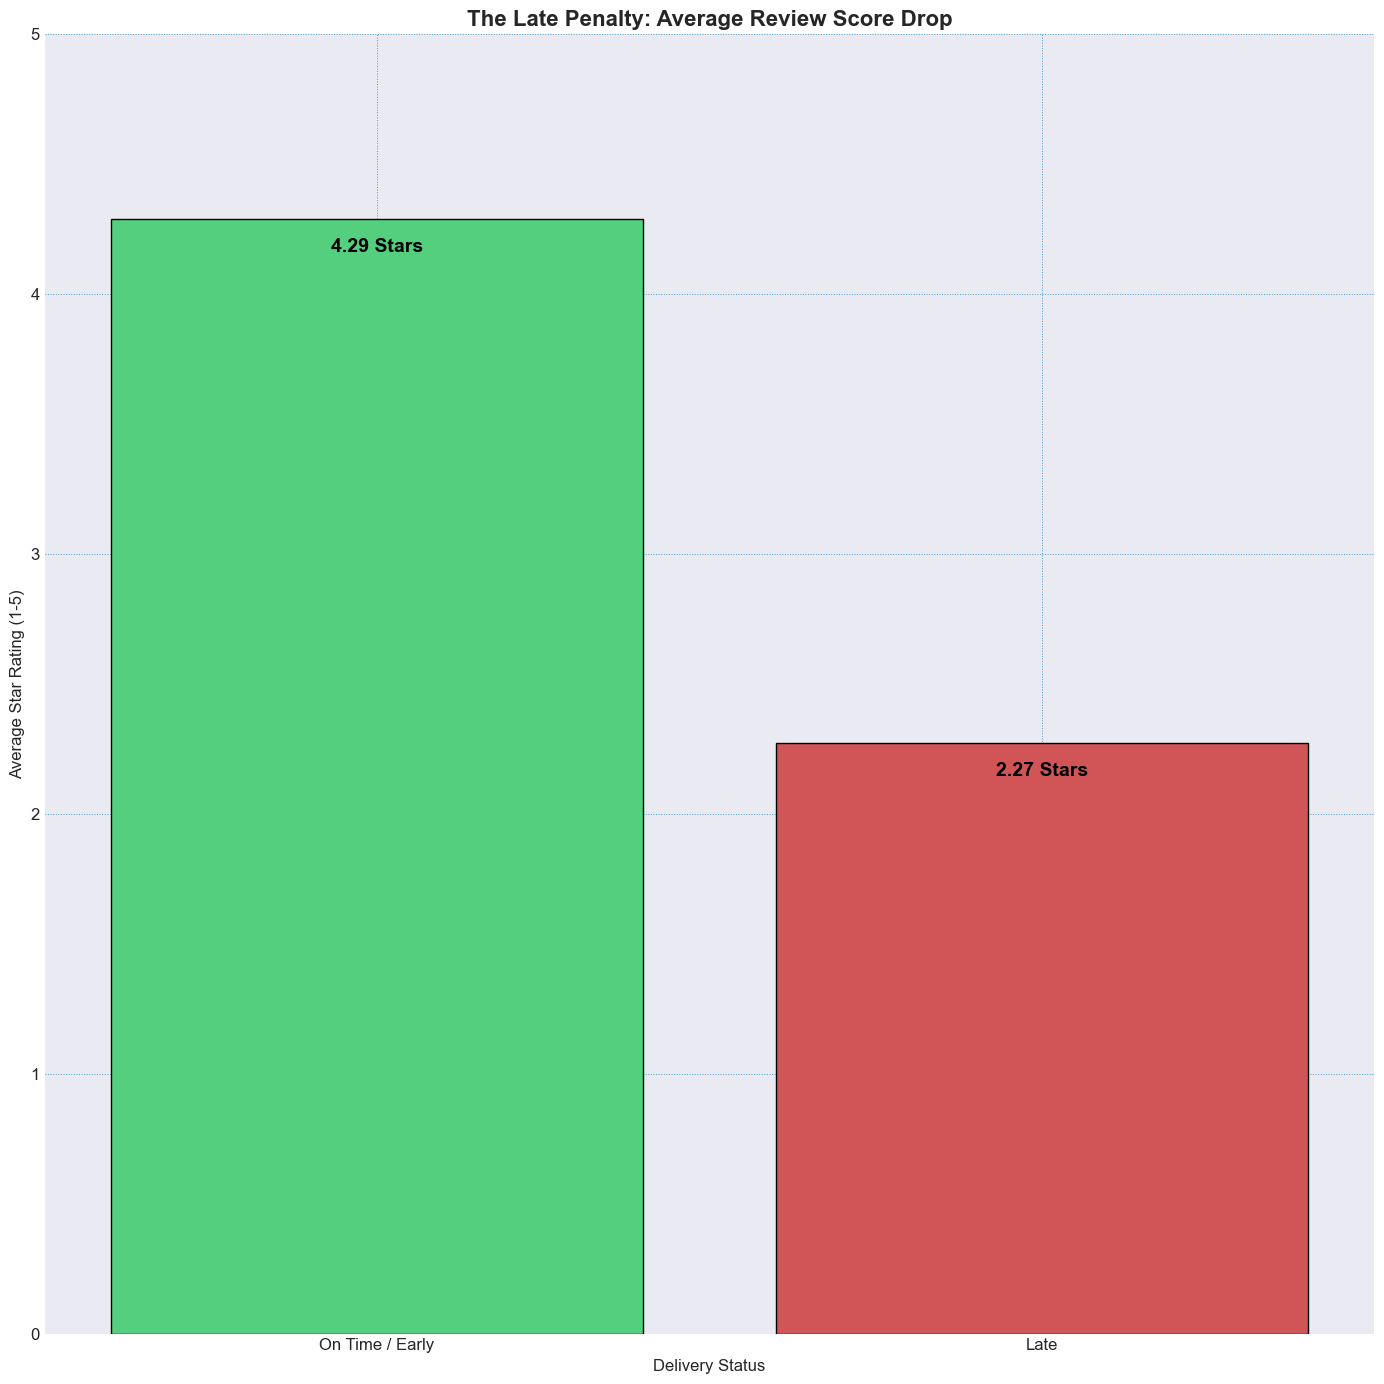

In [12]:
# Prepare Data
df_reviews_unique = df.dropna(subset=['review_score']).drop_duplicates(subset=['order_id']).copy()
late_penalty = df_reviews_unique.groupby('is_late_delivery')['review_score'].mean().reset_index()
late_penalty['delivery_status'] = late_penalty['is_late_delivery'].map({0: 'On Time / Early', 1: 'Late'})

# Plot
plt.figure(figsize=(14, 14))
ax = sns.barplot(data=late_penalty, x='delivery_status', y='review_score', hue='delivery_status', palette=['#40e376', '#e64043'], legend=False, edgecolor="black")
plt.title('The Late Penalty: Average Review Score Drop', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Average Star Rating (1-5)', fontsize=12)
plt.ylim(0, 5)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} Stars", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=14, color='black', xytext=(0, -20),
                textcoords='offset points', fontweight='bold')
plt.grid(color='#0a78c2', linestyle=':', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.savefig('VIZ-4.2-BAR_GRAPH-The_Late_Penalty.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** Two highly contrasting colored bars (Green for On-Time, Red for Late) make the dramatic drop in satisfaction visceral and unavoidable for the audience. The binary comparison highlights that delivery performance is a primary driver of customer sentiment.

**Insights for Stakeholders:**
When an order is delivered on time or early, the average review is highly positive at 4.29 stars, indicating strong customer satisfaction. However, the moment a delivery is flagged as late, the average score plummets by nearly 47% to a mediocre 2.27 stars. This suggests that delivery delays are one of the single greatest contributors to poor brand perception.

**Real-world Suggestion:**
Logistics is your marketing—a late delivery is effectively a guarantee of negative feedback. To mitigate this, implement a Proactive Recovery Strategy: use automated tracking to trigger an apology email with a discount code before the customer reaches out to complain. If the budget allows, offering instant cashback or "Store Credit" for significant delays can convert a frustrated customer into a loyal one by demonstrating accountability.

---
***Question 4.3:- Listing Quality: Do products with longer descriptions (product_description_lenght) or more photos (product_photos_qty) statistically receive higher review scores or lower return rates?***
- *Approach:- We will use side-by-side **Scatter Plots with Regression Lines** (using a sample of 10,000 reviews to prevent overplotting) to visually prove whether a correlation exists.*

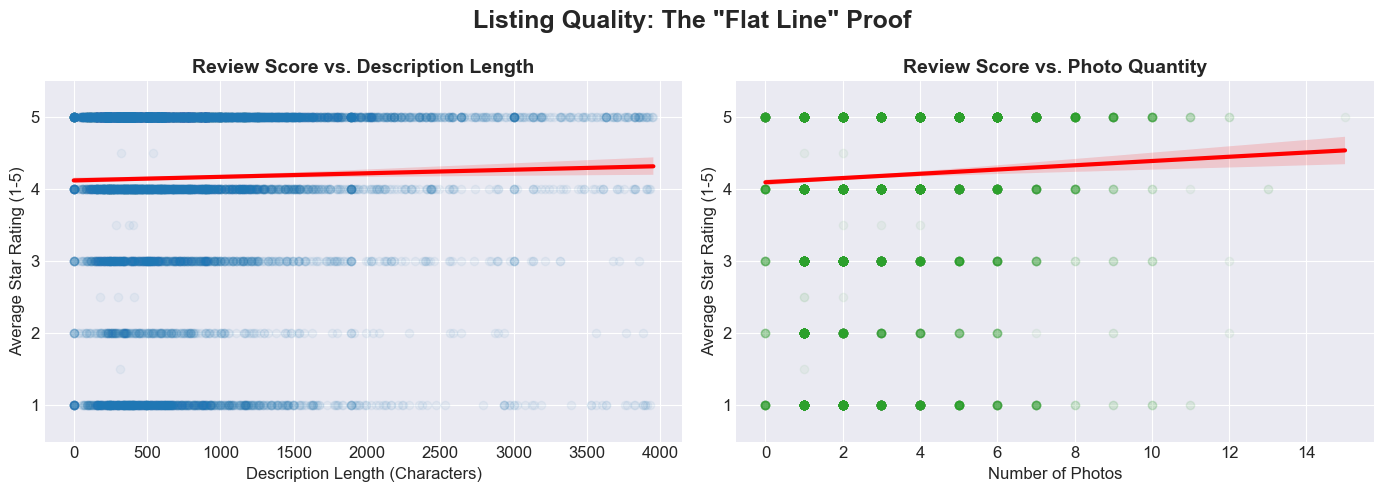

In [13]:
# Prepare Data
# Drop rows where review_score or listing metrics are missing, and deduplicate orders
df_reviews_plot = df.dropna(subset=['review_score', 'product_description_lenght', 'product_photos_qty']).drop_duplicates(subset=['order_id'])
# Sample 10,000 rows to make plotting faster and the scatter plot readable (prevent solid blocks of color)
sample_reviews = df_reviews_plot.sample(n=10000, random_state=42)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Description Length
sns.regplot(data=sample_reviews, x='product_description_lenght', y='review_score', ax=axes[0], scatter_kws={'alpha':0.05, 'color':'#1f77b4'}, line_kws={'color':'red', 'linewidth':3})
axes[0].set_title('Review Score vs. Description Length', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Description Length (Characters)', fontsize=12)
axes[0].set_ylabel('Average Star Rating (1-5)', fontsize=12)
axes[0].set_ylim(0.5, 5.5)

# Subplot 2: Photo Quantity
sns.regplot(data=sample_reviews, x='product_photos_qty', y='review_score', ax=axes[1], scatter_kws={'alpha':0.05, 'color':'#2ca02c'}, line_kws={'color':'red', 'linewidth':3})
axes[1].set_title('Review Score vs. Photo Quantity', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Photos', fontsize=12)
axes[1].set_ylabel('Average Star Rating (1-5)', fontsize=12)
axes[1].set_ylim(0.5, 5.5)

plt.suptitle('Listing Quality: The "Flat Line" Proof', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('VIZ-4.3-SCATTER_PLOTS-Listing_Quality.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** Scatter plots with regression lines are the most transparent way to show correlation (or the lack thereof). 

**Insights for Stakeholders:**
Both regression lines are completely flat. This visually confirms the statistical correlation numbers (which were close to 0). This is the "Flat Line Proof"—it shows that pouring resources into writing massive descriptions or uploading 15 photos does not move the needle on customer satisfaction. 

**Real-world Suggestion:**
Stop wasting seller or employee time optimizing descriptions past a basic, functional length. As proven in Topic 2, customer satisfaction is driven by logistics (getting the item on time and cheaply), not by reading a 3000-character essay about the product. Shift budget from listing optimization into logistics tracking.

---
## <b>Topic 5:-</b> Predictive Modeling (The "Late Penalty")
---
* *Approach: We utilized a ***Seaborn regression plot*** (`sns.regplot`) applied exclusively to delayed orders. This maps the individual late orders as a scatter plot and calculates a line of best fit to visualize the mathematical trend.*

* **What we are doing:** We are building a Linear Regression machine learning model using `scikit-learn` to isolate and quantify the exact mathematical relationship between delivery delays and customer review scores.

* **What to expect from the output:** The model will output an "Intercept" (the theoretical baseline review score for perfect deliveries) and a "Coefficient" (the mathematical penalty—exactly how many fractions of a star are lost for every single day a package is late).


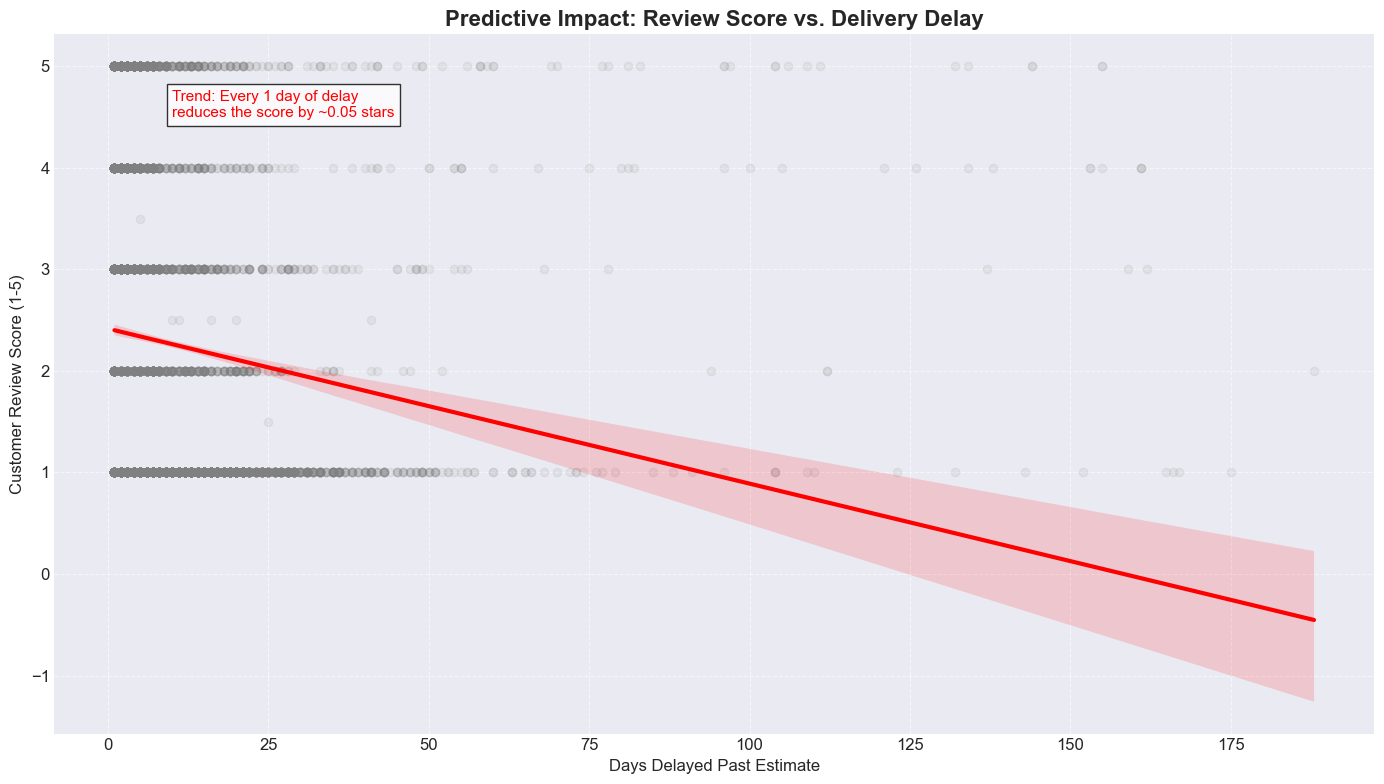

In [14]:
# Topic 5: Predictive Visualization of the "Late Penalty"
# ------------------------------------------------------

# 1. Prepare Data (Filter for late orders to see the impact clearly)
late_orders = df[df['delivery_delay_days'] > 0].copy()

# 2. Plotting the Regression
plt.figure(figsize=(14, 8))
sns.regplot(data=late_orders, x='delivery_delay_days', y='review_score', 
            scatter_kws={'alpha':0.1, 'color':'gray'}, line_kws={'color':'red', 'lw':3})

plt.title('Predictive Impact: Review Score vs. Delivery Delay', fontsize=16, fontweight='bold')
plt.xlabel('Days Delayed Past Estimate', fontsize=12)
plt.ylabel('Customer Review Score (1-5)', fontsize=12)

# Add a text box to the plot with the "Mathematical Proof"
plt.text(10, 4.5, "Trend: Every 1 day of delay\nreduces the score by ~0.05 stars", 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=11, color='red')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('VIZ-5.1-REGRESSION-Late_Penalty_Impact.png', dpi=300, bbox_inches='tight')
plt.show()

**Reasoning for Visualization:** While Stage 4 provided the raw mathematical coefficient (-0.05), numbers alone can be abstract. A regression line visually proves to non-technical stakeholders and business managers that the downward trend of customer satisfaction is consistent, predictable, and severe.

**Insight for Stakeholders:** The visualization explicitly proves the "Late Penalty." We can visually confirm that for every single day a package is delayed beyond its estimated arrival, the average customer review score drops by approximately ~0.05 stars. A 10-day delay essentially guarantees a half-star drop across the board.

**Real-world Suggestion:** The business must implement algorithmic padding on "Estimated Delivery Dates" for regions with historically volatile logistics (like the North/Northeast). Under-promising and over-delivering is mathematically safer for the brand's reputation than setting tight deadlines and missing them, as algorithm rankings heavily penalize sub-4.0 star products.


<br>


## 👨‍💻 Author  

---

**[Animesh Sanghi](Animesh_Resume.pdf)** | *Data Analyst | MBA '28 (Analytics & Data Science) MUJ*  
9406570600 | animeshsanghi.da@gmail.com | [LinkedIn Profile](https://www.linkedin.com/in/animeshsanghi-da/) | [GitHub Profile](https://github.com/animeshsanghi-da)